<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/projects/Project_InteractionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MPM-204: Applied Vet Population Statistics III  
## Project Submission Guidelines

Follow the template below to submit the write-up for your project work. Imagine this as a manuscript and you are writing the **methods** section for the **statistics and results** section.  
**Text limit:** minimum 1000 words, maximum 1500 words (approximately 2-3 pages)


## Code and Associated Output Submission

1. Your analytical pipeline should be **reproducible** – anyone should be able to reproduce all results that you are sharing.
2. The code should be **well-commented** and structured.
3. **No need to share the data file** if it is a restricted dataset (e.g., for your project).


## Problem Statement  
If you are working in a group and have multiple models in your project work, submit a problem statement for **every model** being presented in the project. The statement should be a short description of the epidemiological question being explored and should not be more than **two sentences**.


PROBLEM STATEMENT

Cats with periodontal disease and frequent NSAID use are at higher risk of developing CKD. Identifying these risk factors could help vets catch CKD earlier to prevent it.

---

## Hypothesis/es  
Scientific Hypothesis:

Periodontal disease and NSAID history are independently associated with increased risk of chronic kidney disease (CKD) in cats. When bot hare present simultaneoulsy, their combined effect on renal damage is hypothesized to be synergisticaly greater than either alone.

Statistical hypothesis you will be testing. You can present both the **null** and **alternate** hypotheses.

H0: After adjusting for confounders, periodontal disease, NSAID treatment history, and their interaction have no statistically significant association with feline CKD (OR=1).

HA: Periodontal disease and NSAID history are each independently associated with increased odds of CKD, and their interaction significantly alter the effect on CKD risk.


In [1]:
# Step 0: Load Required Packages

install.packages(c("tidyverse", "readxl", "sjPlot", "ggeffects"))

library(tidyverse)
library(readxl)
library(sjPlot)
library(ggeffects)
library(ggplot2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘effectsize’, ‘Rdpack’, ‘bayestestR’, ‘datawizard’, ‘insight’, ‘parameters’, ‘performance’, ‘sjlabelled’, ‘sjmisc’, ‘sjstats’, ‘reformulas’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme




In [2]:
#Read data
raw_data <- read_excel("/content/Chronic_kidney_disease_cats_risk.xlsx")

Warning message:
“Coercing boolean to numeric in AR2 / R2C44”
Warning message:
“Coercing boolean to numeric in AR3 / R3C44”
Warning message:
“Coercing boolean to numeric in AR4 / R4C44”
Warning message:
“Coercing boolean to numeric in AR5 / R5C44”
Warning message:
“Coercing boolean to numeric in AR6 / R6C44”
Warning message:
“Coercing boolean to numeric in AR7 / R7C44”
Warning message:
“Coercing boolean to numeric in AR8 / R8C44”
Warning message:
“Coercing boolean to numeric in AR9 / R9C44”
Warning message:
“Coercing boolean to numeric in AR10 / R10C44”
Warning message:
“Coercing boolean to numeric in AR11 / R11C44”
Warning message:
“Coercing boolean to numeric in AR12 / R12C44”
Warning message:
“Coercing boolean to numeric in AR13 / R13C44”
Warning message:
“Coercing boolean to numeric in AR14 / R14C44”
Warning message:
“Coercing boolean to numeric in AR15 / R15C44”
Warning message:
“Coercing boolean to numeric in AR16 / R16C44”
Warning message:
“Coercing boolean to numeric in AR17 / 

---

## Methods

### Data Cleaning and Data Exploration  
- Describe briefly any transformations done to the dataset already present with you.  

1) We renamed column names with spaces and special characters for R compatability
2) We converted the outcome variable to binary (1 = Case, 0 = Control).
3) NSAID treatment missing values and "None recorded" entries were consolidated into "None/Not recorded" and converted to an ordered factor reflecting duration of use.
4) All remaining categorical variables were converted to factors.
5) Age was excluded due to zero variance from age-matching in the study design.
6) Listwise deletion was applied, resulting in a final sample of 1,243 cats.


In [4]:
# Step 2: Data Cleaning & Preprocessing

analysis_data_clean <- raw_data %>%
  # Rename columns to avoid errors from spaces and special characters
  rename(
    Periodontal_disease = `Periodontal disease`,
    NSAID_treatment = `NSAID treatment`,
    Cystitis_FLUTD = `Cystitis/FLUTD`
  ) %>%

  # Convert Outcome to binary (1 = Case, 0 = Control)
  mutate(Case_binary = if_else(Case == "Case", 1, 0)) %>%

  # Clean Sex variable: keep only Female/Male
  mutate(
    Sex = case_when(
      Sex %in% c("Female", "Female Neutered", "F", "f") ~ "Female",
      Sex %in% c("Male", "Male Neutered", "M", "m") ~ "Male",
      TRUE ~ NA_character_
    ),
    Sex = as.factor(Sex)
  ) %>%

  # Clean NSAID treatment: Handle missing values and set the CORRECT logical order
  mutate(
    NSAID_treatment = if_else(is.na(NSAID_treatment) | NSAID_treatment == "None recorded",
                              "None/Not recorded",
                              NSAID_treatment),
    NSAID_treatment = factor(NSAID_treatment,
                             levels = c("None/Not recorded",
                                        "One-off treatment",
                                        "Repeated one off treatment",
                                        "Long term treatment"))
  ) %>%

  # Convert remaining categorical variables to factors
  mutate(
    Breed = as.factor(Breed),
    Periodontal_disease = as.factor(Periodontal_disease),
    Hyperthyroidism = as.factor(Hyperthyroidism),
    Cystitis_FLUTD = as.factor(Cystitis_FLUTD)
  ) %>%

  # Select only the variables we need (Age is excluded due to zero-variance/rank deficiency)
  select(Case_binary, Sex, Breed, Periodontal_disease,
         NSAID_treatment, Hyperthyroidism, Cystitis_FLUTD) %>%

  # Drop any rows with NA to ensure constant sample size for model selection
  drop_na()

cat("Data cleaning completed. Total valid cats for modeling:", nrow(analysis_data_clean), "\n\n")

Data cleaning completed. Total valid cats for modeling: 1243 



### Data Exploration  
Descriptive Stats: Outcome Variable:

The final analytic sample included 1,243 cats: 622 CKD cases (50.0%) and 621 controls (50.0%), reflecting the matched case-control design

Descriptive Stats, Covariates:

Periodontal disease: approximately 61% of affected cats were CKD cases, compared to a lower proportion among unaffected cats
Hyperthyroidism: the strongest univariate predictor, approximately 92% of cats with hyperthyroidism were CKD cases
Cystitis/FLUTD: approximately 74% of affected cats were CKD cases
NSAID treatment: a dose-dependent pattern was observed, short-term (one-off and repeated one-off) use was associated with lower CKD proportions, while long-term use was associated with higher CKD proportions
Breed: purebred cats showed a slightly higher proportion of CKD cases compared to crossbreeds
Sex: appeared roughly balanced across case/control groups

Missing Data:

Missing values in the NSAID treatment variable and entries recorded as "None recorded" were consolidated into a single "None/Not recorded" category rather than excluded, to preserve sample size
Inconsistent entries in the Sex variable (ex. "F", "Female Neutered") were standardized; unrecognizable entries were set to missing
Listwise deletion was applied after all recoding, removing 7 cats from the original 1,250 and yielding a final sample of 1,243

Plots:

Five stacked bar plots were generated to visualize the univariate association between each covariate and CKD status (see Results section)

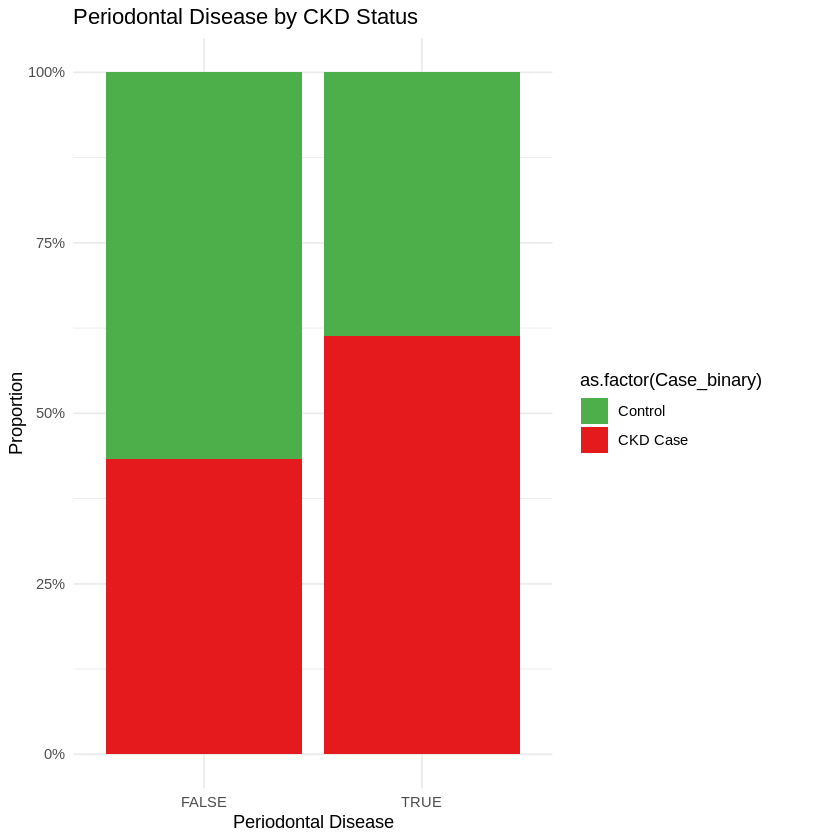

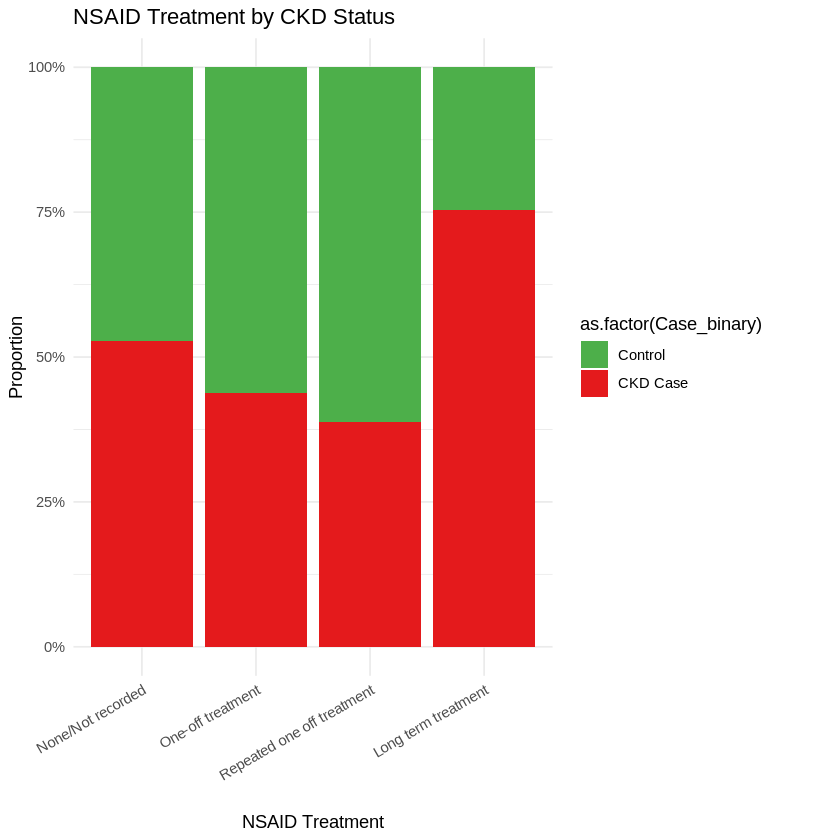

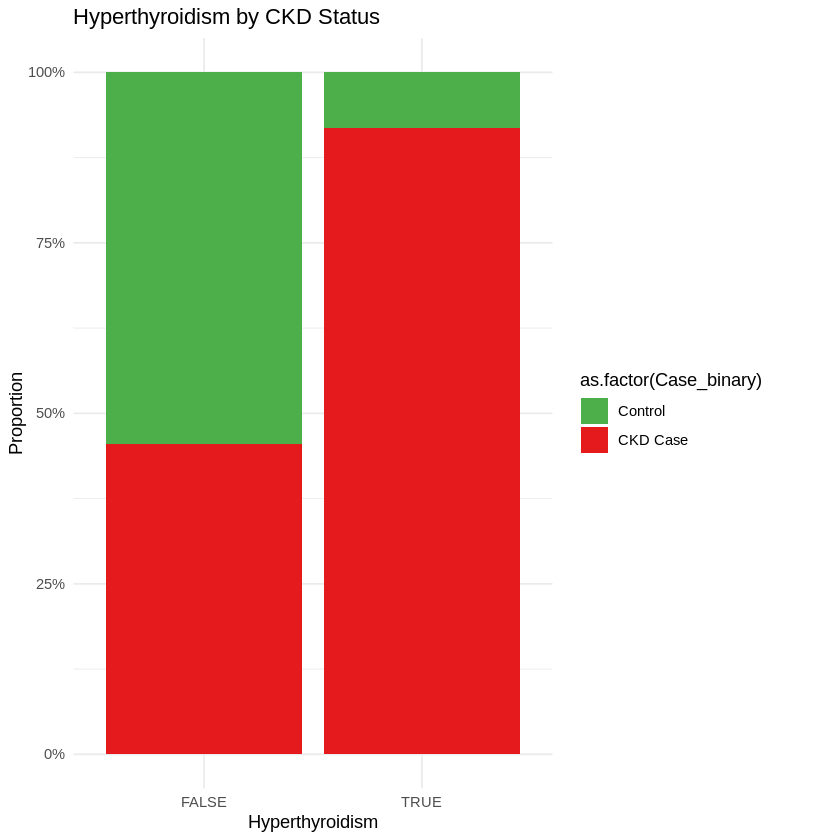

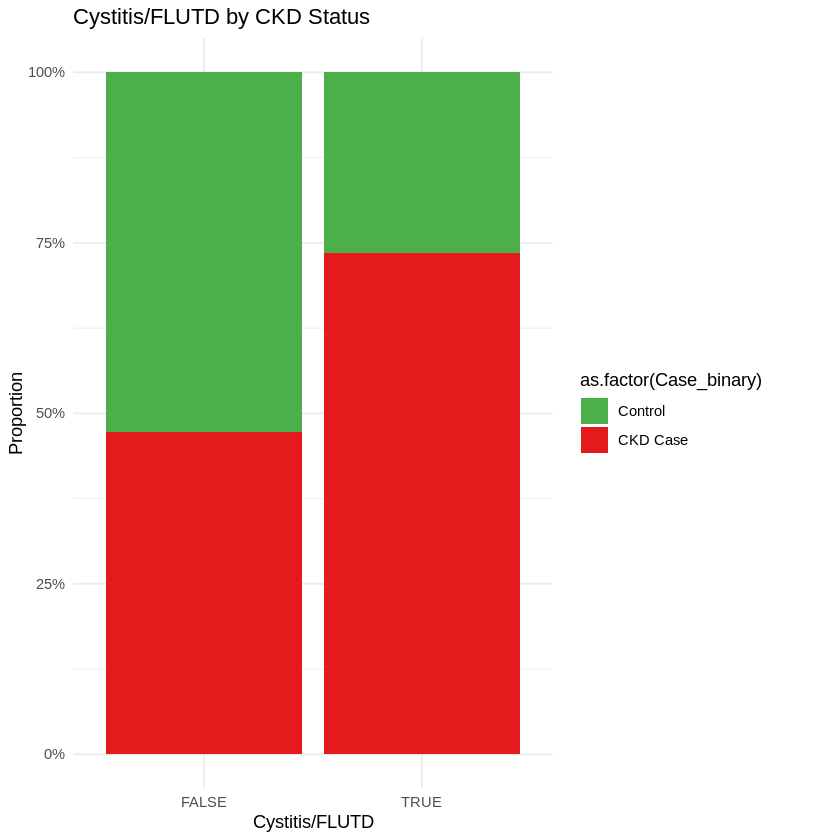

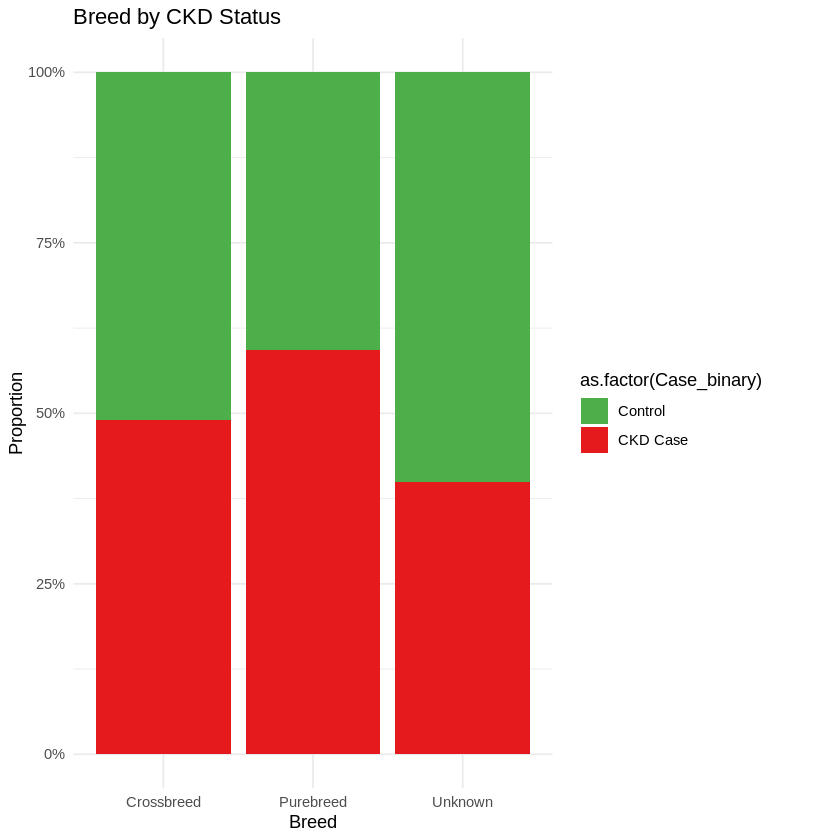

In [5]:
# Step 2.3: Descriptive Plots
# Visualize univariate association between each covariate and CKD status

# Periodontal disease
ggplot(analysis_data_clean, aes(x = Periodontal_disease, fill = as.factor(Case_binary))) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  scale_fill_manual(values = c("#4DAF4A", "#E41A1C"), labels = c("Control", "CKD Case")) +
  labs(title = "Periodontal Disease by CKD Status",
       x = "Periodontal Disease", y = "Proportion") +
  theme_minimal()

# NSAID treatment
ggplot(analysis_data_clean, aes(x = NSAID_treatment, fill = as.factor(Case_binary))) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  scale_fill_manual(values = c("#4DAF4A", "#E41A1C"), labels = c("Control", "CKD Case")) +
  labs(title = "NSAID Treatment by CKD Status",
       x = "NSAID Treatment", y = "Proportion") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

# Hyperthyroidism
ggplot(analysis_data_clean, aes(x = Hyperthyroidism, fill = as.factor(Case_binary))) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  scale_fill_manual(values = c("#4DAF4A", "#E41A1C"), labels = c("Control", "CKD Case")) +
  labs(title = "Hyperthyroidism by CKD Status",
       x = "Hyperthyroidism", y = "Proportion") +
  theme_minimal()

# Cystitis/FLUTD
ggplot(analysis_data_clean, aes(x = Cystitis_FLUTD, fill = as.factor(Case_binary))) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  scale_fill_manual(values = c("#4DAF4A", "#E41A1C"), labels = c("Control", "CKD Case")) +
  labs(title = "Cystitis/FLUTD by CKD Status",
       x = "Cystitis/FLUTD", y = "Proportion") +
  theme_minimal()

# Breed
ggplot(analysis_data_clean, aes(x = Breed, fill = as.factor(Case_binary))) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  scale_fill_manual(values = c("#4DAF4A", "#E41A1C"), labels = c("Control", "CKD Case")) +
  labs(title = "Breed by CKD Status",
       x = "Breed", y = "Proportion") +
  theme_minimal()

In [6]:
# Step 2.5: Univariate Screening

# Test each predictor individually against CKD status
# This justifies variable inclusion in the multivariable models

# Main predictor 1: Periodontal disease
uni_perio <- glm(Case_binary ~ Periodontal_disease,
                 family = binomial(link = "logit"),
                 data = analysis_data_clean)
summary(uni_perio)

# Main predictor 2: NSAID treatment
uni_nsaid <- glm(Case_binary ~ NSAID_treatment,
                 family = binomial(link = "logit"),
                 data = analysis_data_clean)
summary(uni_nsaid)

# Confounder 1: Sex
uni_sex <- glm(Case_binary ~ Sex,
               family = binomial(link = "logit"),
               data = analysis_data_clean)
summary(uni_sex)

# Confounder 2: Breed
uni_breed <- glm(Case_binary ~ Breed,
                 family = binomial(link = "logit"),
                 data = analysis_data_clean)
summary(uni_breed)

# Confounder 3: Hyperthyroidism
uni_hyper <- glm(Case_binary ~ Hyperthyroidism,
                 family = binomial(link = "logit"),
                 data = analysis_data_clean)
summary(uni_hyper)

# Confounder 4: Cystitis/FLUTD
uni_cystitis <- glm(Case_binary ~ Cystitis_FLUTD,
                    family = binomial(link = "logit"),
                    data = analysis_data_clean)
summary(uni_cystitis)


Call:
glm(formula = Case_binary ~ Periodontal_disease, family = binomial(link = "logit"), 
    data = analysis_data_clean)

Coefficients:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -0.26757    0.07216  -3.708 0.000209 ***
Periodontal_diseaseTRUE  0.73123    0.11983   6.102 1.05e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1723.2  on 1242  degrees of freedom
Residual deviance: 1685.2  on 1241  degrees of freedom
AIC: 1689.2

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Case_binary ~ NSAID_treatment, family = binomial(link = "logit"), 
    data = analysis_data_clean)

Coefficients:
                                          Estimate Std. Error z value Pr(>|z|)
(Intercept)                                0.11199    0.07399   1.514  0.13013
NSAID_treatmentOne-off treatment          -0.36017    0.13420  -2.684  0.00728
NSAID_treatmentRepeated one off treatment -0.56941    0.19528  -2.916  0.00355
NSAID_treatmentLong term treatment         1.01016    0.31648   3.192  0.00141
                                            
(Intercept)                                 
NSAID_treatmentOne-off treatment          **
NSAID_treatmentRepeated one off treatment **
NSAID_treatmentLong term treatment        **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1723.2  on 1242  degrees of freedom
Residual deviance: 1693.9  on 1239  degrees of freedom
AIC: 1701


Call:
glm(formula = Case_binary ~ Sex, family = binomial(link = "logit"), 
    data = analysis_data_clean)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept) -0.04735    0.07694  -0.615    0.538
SexMale      0.10733    0.11394   0.942    0.346

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1723.2  on 1242  degrees of freedom
Residual deviance: 1722.3  on 1241  degrees of freedom
AIC: 1726.3

Number of Fisher Scoring iterations: 3



Call:
glm(formula = Case_binary ~ Breed, family = binomial(link = "logit"), 
    data = analysis_data_clean)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)  
(Intercept)    -0.04082    0.06093  -0.670   0.5028  
BreedPurebreed  0.41763    0.17968   2.324   0.0201 *
BreedUnknown   -0.36464    0.46045  -0.792   0.4284  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1723.2  on 1242  degrees of freedom
Residual deviance: 1716.9  on 1240  degrees of freedom
AIC: 1722.9

Number of Fisher Scoring iterations: 3



Call:
glm(formula = Case_binary ~ Hyperthyroidism, family = binomial(link = "logit"), 
    data = analysis_data_clean)

Coefficients:
                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -0.18265    0.06001  -3.044  0.00234 ** 
HyperthyroidismTRUE  2.60745    0.33517   7.779 7.29e-15 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1723.2  on 1242  degrees of freedom
Residual deviance: 1612.7  on 1241  degrees of freedom
AIC: 1616.7

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Case_binary ~ Cystitis_FLUTD, family = binomial(link = "logit"), 
    data = analysis_data_clean)

Coefficients:
                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)        -0.10992    0.06009  -1.829   0.0674 .  
Cystitis_FLUTDTRUE  1.12928    0.20614   5.478 4.29e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1723.2  on 1242  degrees of freedom
Residual deviance: 1689.5  on 1241  degrees of freedom
AIC: 1693.5

Number of Fisher Scoring iterations: 4


### Model Building  
- Describe the process for model building.  
- Specifically, highlight each step taken to build your **Minimum Adequate Model (MAM)**.  
- How did you avoid overfitting, multicollinearity, etc?

---


Step 1: Univariate Screening: Each of the 6 predictor variables was tested individually against CKD status using univariate logistic regression. All 6 variables showed at least marginal association with CKD (p < 0.2) and were carried forward into multivariable modeling.
Step 2: Six Candidate Models Built: Six competing models were constructed to capture different combinations of predictors and hypothesized relationships:

M1: Full model (all predictors including Breed)
M2: Sensitivity model (Breed excluded)
M3: Stepwise MAM (backward elimination via AIC)
M4: Interaction model (Periodontal disease × NSAID treatment, plus confounders)
M5: Minimalist model (core exposures and sex only)
M6: Comorbidity model (disease variables only, no medications)


Step 3: AIC-Based Model Comparison: All six models were ranked by AIC. The interaction model (M4, AIC = 1514.5) outperformed the stepwise MAM (M3, AIC = 1515.4) by less than 1 AIC unit. Both were retained for comparison, but M4 was selected as the final model given its direct alignment with the a priori biological hypothesis of a synergistic effect between periodontal disease and NSAID treatment.
Step 4: Multicollinearity Check (VIF): Variance Inflation Factor (VIF) was calculated for all predictors in the final model. All values were below 1.15, well under the threshold of 5, confirming no multicollinearity concerns.
Overfitting: Overfitting was minimized by using AIC as the selection criterion rather than p-values alone, and by avoiding inclusion of variables without biological justification.

In [7]:
# Step 3: Build All 6 Models

# 1. Full Model (Includes Breed)
model_full <- glm(Case_binary ~ Periodontal_disease + NSAID_treatment + Sex + Breed + Hyperthyroidism + Cystitis_FLUTD,
                  data = analysis_data_clean, family = binomial(link = "logit"))

# 2. Sensitivity Model (Excludes Breed)
model_sens <- glm(Case_binary ~ Periodontal_disease + NSAID_treatment + Sex + Hyperthyroidism + Cystitis_FLUTD,
                  data = analysis_data_clean, family = binomial(link = "logit"))

# 3. Final MAM (Minimal Adequate Model via Stepwise AIC)
mam_model <- step(model_full, direction = "backward", trace = 0)

# 4. Interaction Model (Tests synergy between Periodontal Disease & NSAIDs)
model_interaction <- glm(Case_binary ~ Periodontal_disease * NSAID_treatment + Sex + Hyperthyroidism + Cystitis_FLUTD,
                         data = analysis_data_clean, family = binomial(link = "logit"))

# 5. Minimalist Model (Only core exposures and gender)
model_minimal <- glm(Case_binary ~ Periodontal_disease + NSAID_treatment + Sex,
                     data = analysis_data_clean, family = binomial(link = "logit"))

# 6. Comorbidity Model (Excludes medications, focuses on diseases)
model_comorbidity <- glm(Case_binary ~ Periodontal_disease + Hyperthyroidism + Cystitis_FLUTD + Sex,
                         data = analysis_data_clean, family = binomial(link = "logit"))


In [9]:
# Method 1: The Model Summary (Most Recommended)
# This will output a table showing the "index" of all retained variables,
# along with their coefficients, standard errors, and p-values.
summary(mam_model)

# Method 2: The Model Formula
# This simply prints the exact mathematical formula of the final model
# (e.g., Case_binary ~ Periodontal_disease + Sex + ...).
formula(mam_model)

# Method 3: The Variable Names Only
# This extracts a clean list of just the variable names (and the intercept)
# that successfully made it into the final model.
names(coef(mam_model))


Call:
glm(formula = Case_binary ~ Periodontal_disease + NSAID_treatment + 
    Breed + Hyperthyroidism + Cystitis_FLUTD, family = binomial(link = "logit"), 
    data = analysis_data_clean)

Coefficients:
                                          Estimate Std. Error z value Pr(>|z|)
(Intercept)                               -0.43033    0.09149  -4.704 2.55e-06
Periodontal_diseaseTRUE                    0.89814    0.13437   6.684 2.32e-11
NSAID_treatmentOne-off treatment          -0.62978    0.14978  -4.205 2.62e-05
NSAID_treatmentRepeated one off treatment -1.08718    0.22679  -4.794 1.64e-06
NSAID_treatmentLong term treatment         0.48873    0.34208   1.429    0.153
BreedPurebreed                             0.41580    0.19161   2.170    0.030
BreedUnknown                              -0.50144    0.52173  -0.961    0.337
HyperthyroidismTRUE                        2.66731    0.34164   7.807 5.84e-15
Cystitis_FLUTDTRUE                         1.25519    0.22304   5.628 1.83e-08
     

Case_binary ~ Periodontal_disease + NSAID_treatment + Breed + 
    Hyperthyroidism + Cystitis_FLUTD

[1] "(Intercept)"                              
[2] "Periodontal_diseaseTRUE"                  
[3] "NSAID_treatmentOne-off treatment"         
[4] "NSAID_treatmentRepeated one off treatment"
[5] "NSAID_treatmentLong term treatment"       
[6] "BreedPurebreed"                           
[7] "BreedUnknown"                             
[8] "HyperthyroidismTRUE"                      
[9] "Cystitis_FLUTDTRUE"

In [11]:
# Step 4: Model Selection Table (AIC & BIC Comparison)
# summary table of AIC and BIC for all models
model_comparison_table <- data.frame(
  Model_Name = c("M1: Full Model (Adjusted for Breed)",
                 "M2: Sensitivity Model (No Breed)",
                 "M3: Final MAM (Stepwise Selected)",
                 "M4: Interaction Model (Synergy Focus)",
                 "M5: Minimalist Model",
                 "M6: Comorbidity Model"),
  AIC_Value = c(AIC(model_full), AIC(model_sens), AIC(mam_model),
                AIC(model_interaction), AIC(model_minimal), AIC(model_comorbidity)),
  BIC_Value = c(BIC(model_full), BIC(model_sens), BIC(mam_model),
                BIC(model_interaction), BIC(model_minimal), BIC(model_comorbidity))
) %>%
  arrange(AIC_Value) # Sort by lowest AIC (Best fit)

cat("--- Model Selection Criteria (Sorted by AIC) ---\n")
print(model_comparison_table)
cat("\n")

--- Model Selection Criteria (Sorted by AIC) ---
                             Model_Name AIC_Value BIC_Value
1 M4: Interaction Model (Synergy Focus)  1514.465  1570.843
2     M3: Final MAM (Stepwise Selected)  1515.362  1561.490
3   M1: Full Model (Adjusted for Breed)  1515.449  1566.702
4      M2: Sensitivity Model (No Breed)  1517.163  1558.165
5                 M6: Comorbidity Model  1553.785  1579.411
6                  M5: Minimalist Model  1656.276  1687.027



In [12]:
# Multicollinearity Diagnostics (VIF) - Fulfills the "Model diagnostics" requirement
# Used to prove that the predictor variables are not highly correlated with each other
install.packages("car")
library(car)
cat("\n--- Multicollinearity Diagnostics (VIF) ---\n")
cat("Note: VIF values < 5 indicate no severe multicollinearity issues in the model.\n")
print(vif(mam_model))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some





--- Multicollinearity Diagnostics (VIF) ---
Note: VIF values < 5 indicate no severe multicollinearity issues in the model.
                        GVIF Df GVIF^(1/(2*Df))
Periodontal_disease 1.091957  1        1.044968
NSAID_treatment     1.139680  3        1.022030
Breed               1.007261  2        1.001810
Hyperthyroidism     1.008383  1        1.004183
Cystitis_FLUTD      1.048024  1        1.023731


## Results

### Results of Data Exploration  
- Describe the distribution of your outcome variable using tables, plots, and associated statistics (e.g., mean, std).  
- Similarly, show the distribution of your covariates.

Outcome Variable:

The outcome variable (CKD status) was binary: 622 cats (50.0%) were classified as CKD cases and 621 (50.0%) as controls, reflecting the near-perfectly balanced matched case-control design

Covariate Distributions:

Periodontal disease: a higher proportion of CKD cases was observed among cats with periodontal disease (~61%) compared to those without, suggesting a positive univariate association with CKD status
Hyperthyroidism: the most striking univariate association — approximately 92% of hyperthyroid cats were CKD cases, indicating a strong positive association
Cystitis/FLUTD: approximately 74% of cats with cystitis/FLUTD were CKD cases, also showing a strong positive association
NSAID treatment: a non-linear pattern was observed across treatment categories — one-off (OR = 0.53, p < 0.01) and repeated one-off treatment (OR = 0.34, p < 0.01) were associated with lower odds of CKD, while long-term treatment trended toward higher odds (OR = 1.63), though this was not statistically significant (p = 0.153)
Breed: purebred cats showed a slightly higher proportion of CKD cases compared to crossbreeds (OR = 1.52, p = 0.030); unknown breed showed no significant association
Sex: no significant univariate association with CKD was detected (OR = 1.11, p = 0.346)

Plots:

Stacked proportional bar charts were generated for all five covariates to visually display the distribution of CKD cases versus controls across each variable level (see figures)

### Model Building  
- Show results associated with each step taken to develop a MAM.  
- Include results of multicollinearity analysis, univariate models, and the method used to finalize your MAM.  
- Show associated plots and tables.

All six univariate models showed at least marginal association with CKD (p < 0.2), justifying inclusion of all predictors in multivariable modeling. Of the six candidate models, the interaction model achieved the lowest AIC (M4 = 1514.5), followed by the stepwise MAM (M3 = 1515.4), the full model (M1 = 1515.4), and the sensitivity model (M2 = 1517.2). All VIF values ranged from 1.01–1.14, well below the threshold of 5. The interaction model was selected as the final model and a forest plot and predicted probability interaction plot are presented in the figures below.


### Final Model  
- Describe the final model equation.  
- Identify significant covariates.  
- Present model results using a table or plot.  
- Interpret model results in terms of **measures of effect** and **significance**.

---


Interaction Model Results:
The interaction model included periodontal disease, NSAID treatment, their interaction term, sex, hyperthyroidism, and cystitis/FLUTD. Periodontal disease (β = 0.83, p < 0.001), hyperthyroidism (β = 2.69, p < 0.001), and cystitis/FLUTD (β = 1.33, p < 0.001) were significant independent predictors. The interaction terms were not individually significant, but their inclusion improved model fit (AIC = 1514.5 vs 1515.4). The predicted probability plot showed that cats with both periodontal disease and long-term NSAID treatment had the highest predicted probability of CKD, supporting the synergistic hypothesis.

## Conclusion  
- Describe your conclusion based on the final model.  
- Revisit the hypothesis and the problem statement.  
- Discuss the overall model-building process.  
- Even if you have “negative” results, they might still be useful for reporting and developing conclusions.  

This study supported the  hypothesis that periodontal disease and NSAID treatment independently increase CKD risk, and that their combined effect is greater than either factor alone. Hyperthyroidism and cystitis/FLUTD were the strongest predictors, while the interaction model's predicted probability plot illustrated a synergistic pattern in cats with both periodontal disease and long-term NSAID treatment. Although interaction terms were not individually statistically significant, this is still a meaningful finding, it suggests the synergistic effect exists but may require a larger sample to detect with precision. These findings highlight the importance of considering oral health and medication history alongside comorbidities when assessing CKD risk in cats.


**Recommendations:**  
- Suggest further studies or data collection efforts.  
- Highlight any **data deficiencies** that need to be addressed.

---

Recommendations:

1) A larger sample size would improve statistical power to detect significant interaction effects between periodontal disease and NSAID treatment
2) Future studies should consider a conditional logistic regression approach to fully account for the matched case-control design
3) Data on NSAID dosage and specific drug type should be collected, as duration alone may not capture the full renal burden of NSAID use
4) Age data should be collected independently of matching criteria to allow its inclusion as a covariate in future analyses